In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from torchvision.datasets import EuroSAT
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [3]:
mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

In [4]:
train_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])
test_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

In [5]:
class TfDataset(Dataset):
  def __init__(self, subset, tf):
    self.subset = subset
    self.tf = tf

  def __len__(self):
    return len(self.subset)

  def __getitem__(self, idx):
    img, label = self.subset[idx]
    return self.tf(img), label

In [8]:
full = EuroSAT(root='./data', download=True)
classes = full.classes
n_train = int(0.8 * len(full))
g = torch.Generator().manual_seed(42)
train_sub, test_sub = random_split(full, [n_train, len(full)- n_train], generator = g)

In [9]:
train_loader = DataLoader(TfDataset(train_sub, train_tf), batch_size = 64, shuffle = True, num_workers = 4)
test_loader = DataLoader(TfDataset(test_sub, test_tf), batch_size = 64, shuffle = False, num_workers = 4)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [10]:
model = models.resnet50(weights = models.ResNet50_Weights.IMAGENET1K_V1)
for p in model.parameters():
  p.requires_grad = False
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.fc.in_features, 10)
)
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr = 1e-3)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 192MB/s]


In [13]:
def run_epoch(loader, train = True):
  model.train() if train else model.eval()
  total, correct, loss_sum = 0, 0, 0.0
  with torch.set_grad_enabled(train):
    for x, y in loader:
      x, y = x.to(device), y.to(device)
      out = model(x)
      loss = criterion(out, y)
      if train:
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
      loss_sum += loss.item() * x.size(0)
      correct += (out.argmax(1) == y).sum().item()
      total += x.size(0)
    return loss_sum / total, correct / total

In [14]:
print("--Training Classifier head--")
for e in range(5):
  tr = run_epoch(train_loader, train = True)
  te = run_epoch(test_loader, train = False)
  print(f' Epoch {e+1}: train_acc = {tr[1]:.3f} | test_acc = {te[1]:.3f}')

--Training Classifier head--


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


 Epoch 1: train_acc = 0.789 | test_acc = 0.884
 Epoch 2: train_acc = 0.865 | test_acc = 0.889
 Epoch 3: train_acc = 0.875 | test_acc = 0.880
 Epoch 4: train_acc = 0.878 | test_acc = 0.900
 Epoch 5: train_acc = 0.886 | test_acc = 0.892


In [15]:
print("--Fine Tuning Layer--")
for p in model.layer4.parameters():
  p.requires_grad = True
optimizer = torch.optim.Adam([{'params': model.layer4.parameters(),'lr': 1e-5},
                              {'params': model.fc.parameters(), 'lr': 1e-4}])
for e in range(5):
  tr = run_epoch(train_loader, train = True)
  te = run_epoch(test_loader, train = False)
  print(f' Epoch {e+1}: train_acc = {tr[1]:.3f} | test_acc = {te[1]:.3f}')

torch.save(model.state_dict(), 'eurosat_resnet50.pth')
print('Saved model -> eurosat_resnet50.pth')

--Fine Tuning Layer--


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


 Epoch 1: train_acc = 0.919 | test_acc = 0.945
 Epoch 2: train_acc = 0.944 | test_acc = 0.961
 Epoch 3: train_acc = 0.956 | test_acc = 0.964
 Epoch 4: train_acc = 0.961 | test_acc = 0.967
 Epoch 5: train_acc = 0.964 | test_acc = 0.971
Saved model -> eurosat_resnet50.pth


In [16]:
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for x, y in test_loader:
        out = model(x.to(device))
        y_pred += out.argmax(1).cpu().tolist(); y_true += y.tolist()

print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=classes))

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



Classification Report:
                       precision    recall  f1-score   support

          AnnualCrop       0.97      0.97      0.97       631
              Forest       0.99      0.99      0.99       582
HerbaceousVegetation       0.97      0.96      0.97       612
             Highway       0.95      0.98      0.96       525
          Industrial       0.99      0.96      0.97       484
             Pasture       0.95      0.96      0.96       396
       PermanentCrop       0.96      0.94      0.95       506
         Residential       0.97      0.99      0.98       606
               River       0.96      0.97      0.96       497
             SeaLake       1.00      0.98      0.99       561

            accuracy                           0.97      5400
           macro avg       0.97      0.97      0.97      5400
        weighted avg       0.97      0.97      0.97      5400



Saved confusion_matrix.png


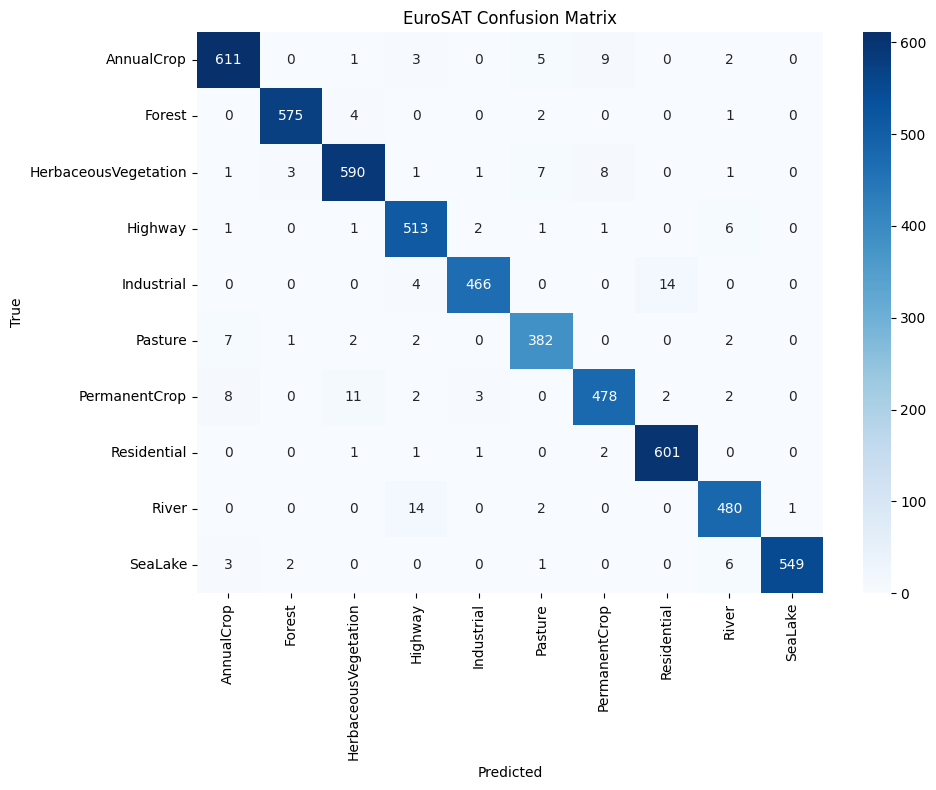

In [17]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("EuroSAT Confusion Matrix")
plt.tight_layout(); plt.savefig("confusion_matrix.png", dpi=150)
print("Saved confusion_matrix.png")

Saved gradcam.png


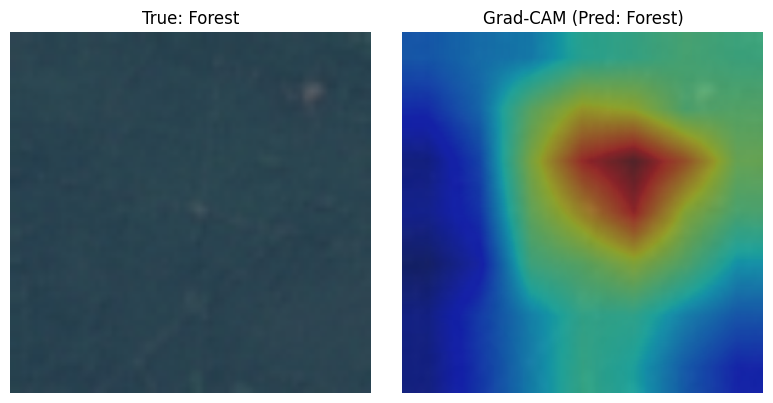

In [18]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model, self.grads, self.acts = model, None, None
        target_layer.register_forward_hook(self._fwd)
        target_layer.register_full_backward_hook(self._bwd)
    def _fwd(self, m, i, o): self.acts = o.detach()
    def _bwd(self, m, gi, go): self.grads = go[0].detach()
    def __call__(self, x, cls=None):
        out = self.model(x)
        cls = out.argmax(1) if cls is None else cls
        self.model.zero_grad()
        out[0, cls].backward()
        w = self.grads.mean(dim=(2, 3), keepdim=True)
        cam = torch.relu((w * self.acts).sum(1)).squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() + 1e-8)
        return cam, cls.item()

cam_engine = GradCAM(model, model.layer4[-1])
img, label = TfDataset(test_sub, test_tf)[0]
cam, pred = cam_engine(img.unsqueeze(0).to(device))

# Overlay
inv = img.cpu().numpy().transpose(1, 2, 0) * np.array(std) + np.array(mean)
inv = np.clip(inv, 0, 1)
import cv2
heat = cv2.resize(cam, (224, 224))
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1); plt.imshow(inv); plt.title(f"True: {classes[label]}"); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(inv); plt.imshow(heat, cmap="jet", alpha=0.5)
plt.title(f"Grad-CAM (Pred: {classes[pred]})"); plt.axis("off")
plt.tight_layout(); plt.savefig("gradcam.png", dpi=150)
print("Saved gradcam.png")